# 02 – Data Cleaning and Preprocessing

Transforms the raw Cell2Cell dataset into a clean, fully numerical, model-ready format. All decisions follow directly from findings in Notebook 01. The preprocessing pipeline is fitted on training data only; test and holdout sets are transformed without refitting.

**Steps covered:**
1. Drop `CustomerID` (identifier), `ServiceArea` (747-cardinality), and `NotNewCellphoneUser` (collinear)
2. Replace `'Unknown'` strings with NaN; encode `Churn` as binary `0`/`1`
3. Apply median imputation + standard scaling (numerical) and most-frequent imputation + one-hot encoding (categorical)
4. Remove constant features via `VarianceThreshold` (99 → 98); select top 50 via `SelectKBest` (ANOVA F-score)
5. Save all processed outputs and the fitted pipeline for Notebooks 03–09

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

## Load Data

In [2]:
train_df = pd.read_csv("../data/raw/cell2celltrain.csv")
holdout_df = pd.read_csv("../data/raw/cell2cellholdout.csv")
display(train_df.head())
display(holdout_df.head())
print("Train shape:", train_df.shape)
print("Holdout shape:", holdout_df.shape)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000006,NaN,57.49,483.0,37.0,0.25,23.0,0.0,532.0,51.0,...,0,5,No,1,150,No,5-Low,Other,Other,No
1,3000018,NaN,55.23,570.0,72.0,0.00,0.0,0.0,38.0,0.0,...,0,6,No,2,80,No,1-Highest,Other,Professional,No
2,3000034,NaN,97.34,1039.0,50.0,4.95,420.0,0.0,198.0,23.3,...,0,4,No,3,10,No,3-Good,Suburban,Crafts,Yes
3,3000070,NaN,35.59,153.0,30.0,0.00,16.0,0.0,30.0,7.3,...,0,4,No,1,200,No,1-Highest,Other,Other,No
4,3000074,NaN,55.27,1213.0,50.0,0.74,0.0,1.3,169.0,1.0,...,0,3,No,0,10,No,1-Highest,Suburban,Other,No


Train shape: (51047, 58)
Holdout shape: (20000, 58)


## Drop CustomerID

`CustomerID` is a unique row identifier with no predictive value — dropped from both datasets.


In [3]:
# Drop CustomerID from both datasets — it is a non-predictive identifier
train_df = train_df.drop(columns=["CustomerID"])
holdout_df = holdout_df.drop(columns=["CustomerID"])

print("Train shape after dropping CustomerID:", train_df.shape)
print("Holdout shape after dropping CustomerID:", holdout_df.shape)

Train shape after dropping CustomerID: (51047, 57)
Holdout shape after dropping CustomerID: (20000, 57)


## Replace ‘Unknown’ Strings with NaN

Three features (`HandsetPrice`, `MaritalStatus`, `Homeownership`) use the string `'Unknown'` to represent missing data. These are not caught by `.isna()`, so they are explicitly replaced with NaN before the pipeline runs, ensuring consistent imputation.

In [4]:
# Replace 'Unknown' string entries with NaN across all object columns
# This ensures hidden missing values are handled by the imputation pipeline
for col in train_df.select_dtypes(include="object").columns:
    train_df[col] = train_df[col].replace("Unknown", np.nan)

for col in holdout_df.select_dtypes(include="object").columns:
    holdout_df[col] = holdout_df[col].replace("Unknown", np.nan)

# Confirm the replacement worked
print("Remaining 'Unknown' string values in train:")
for col in train_df.select_dtypes(include="object").columns:
    count = (train_df[col].astype(str).str.strip().str.lower() == "unknown").sum()
    if count > 0:
        print(f"  {col}: {count}")
print("Done — all Unknown strings replaced with NaN.")

Remaining 'Unknown' string values in train:
Done — all Unknown strings replaced with NaN.


## Encode Target Variable

Encode `Churn` as binary (0 = No, 1 = Yes) and verify class distribution:


In [5]:
target_col = "Churn"

# Separate features and target
X = train_df.drop(columns=[target_col])
y = train_df[target_col]

# Convert target to binary 0/1
if y.dtype == "object":
    y = y.astype(str).str.strip().map({"No": 0, "Yes": 1})

print("Target distribution (counts):")
print(y.value_counts(dropna=False))

print("\nTarget distribution (proportions):")
print(y.value_counts(normalize=True))

Target distribution (counts):
Churn
0    36336
1    14711
Name: count, dtype: int64

Target distribution (proportions):
Churn
0    0.711815
1    0.288185
Name: proportion, dtype: float64


## Drop ServiceArea

With 747 unique values, `ServiceArea` is unsuitable for one-hot encoding. Target encoding (replacing each area with its mean churn rate) would require computing means before the train/test split, which risks data leakage from test labels. The cleanest solution is to drop this feature entirely — geographic service area is unlikely to be a primary driver of individual churn behaviour compared to usage and behavioural features.

In [6]:
# Create holdout features
X_holdout = holdout_df.drop(columns=[target_col], errors="ignore")

# Drop ServiceArea — 747 unique values make it unsuitable for one-hot encoding.
# Target encoding would require computing churn rates before the train/test split,
# introducing data leakage. Dropping is the cleaner, leakage-free choice.
X = X.drop(columns=["ServiceArea"])
X_holdout = X_holdout.drop(columns=["ServiceArea"])

print("ServiceArea dropped.")
print("Training features shape:", X.shape)
print("Holdout features shape:", X_holdout.shape)

ServiceArea dropped.
Training features shape: (51047, 55)
Holdout features shape: (20000, 55)


## Drop Redundant Column — NotNewCellphoneUser

`NewCellphoneUser` and `NotNewCellphoneUser` were flagged in Notebook 01 as likely complementary binary features. The crosstab below shows they are not perfect logical inverses — 34,188 rows have both set to `'No'` — but `NewCellphoneUser = Yes` never co-occurs with `NotNewCellphoneUser = Yes`, confirming strong redundancy. Retaining both would introduce near-collinearity into the encoded feature matrix; `NotNewCellphoneUser` is dropped as the less informative of the two.

In [7]:
# Verify the two features are logical inverses
cross = pd.crosstab(X["NewCellphoneUser"], X["NotNewCellphoneUser"])
print(cross)

# Drop the redundant column from both feature sets
X = X.drop(columns=["NotNewCellphoneUser"])
X_holdout = X_holdout.drop(columns=["NotNewCellphoneUser"])
print("\nNotNewCellphoneUser dropped.")
print("Training features shape:", X.shape)
print("Holdout features shape:", X_holdout.shape)

NotNewCellphoneUser     No   Yes
NewCellphoneUser                
No                   34188  7035
Yes                   9824     0

NotNewCellphoneUser dropped.
Training features shape: (51047, 54)
Holdout features shape: (20000, 54)


## Verify IncomeGroup = 0

Notebook 01 flagged that `IncomeGroup = 0` may represent missing or unknown income rather than a valid income tier. Verified below before it enters the pipeline.

In [8]:
zero_count = (X["IncomeGroup"] == 0).sum()
zero_pct = zero_count / len(X) * 100
churn_rate_zero = y[X["IncomeGroup"] == 0].mean()
churn_rate_nonzero = y[X["IncomeGroup"] != 0].mean()

print(f"IncomeGroup = 0: {zero_count} rows ({zero_pct:.1f}% of training set)")
print(f"Churn rate where IncomeGroup=0:  {churn_rate_zero:.3f}")
print(f"Churn rate where IncomeGroup!=0: {churn_rate_nonzero:.3f}")
print()
if abs(churn_rate_zero - churn_rate_nonzero) > 0.05:
    print("IncomeGroup=0 shows a meaningfully different churn rate — retaining as a valid predictor.")
else:
    print("IncomeGroup=0 churn rate is similar to other groups — consistent with a valid low-income tier, not a missing-value code. Retained as-is.")

IncomeGroup = 0: 12835 rows (25.1% of training set)
Churn rate where IncomeGroup=0:  0.302
Churn rate where IncomeGroup!=0: 0.283

IncomeGroup=0 churn rate is similar to other groups — consistent with a valid low-income tier, not a missing-value code. Retained as-is.


## Define Feature Groups

In [9]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numerical features:  {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features:  34
Categorical features: 20


### Define Preprocessing Pipelines

Two sub-pipelines are defined:
- **Numerical:** median imputation (robust to the outliers identified in Notebook 01) → standard scaling
- **Categorical:** most-frequent imputation → one-hot encoding (`handle_unknown='ignore'` handles any unseen categories in the holdout set)

In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

### Build Full Preprocessing Pipeline

A `ColumnTransformer` combines both sub-pipelines, routing each feature group to the correct transformations in a single unified step.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Fit Pipeline and Transform

The dataset is split 80/20 (stratified, `random_state=42`) **before** any fitting. The preprocessing pipeline is fitted on the 80% training rows only. The fitted pipeline is then applied to all rows via `transform()` (so downstream notebooks can re-split identically with the same seed) and to the holdout set — no refitting on either.

In [12]:
# Split FIRST — preprocessing must only see training rows
X_train_nb02, X_test_nb02, y_train_nb02, y_test_nb02 = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit on TRAINING rows only — test rows never influence scaling, imputation, or encoding
X_train_processed = preprocessor.fit_transform(X_train_nb02)

# Transform ALL rows with the train-fitted pipeline
# Downstream notebooks re-split with the same random_state=42, so they get correct train/test subsets
X_processed = preprocessor.transform(X)

# Transform holdout using the same fitted pipeline — no refitting
X_holdout_processed = preprocessor.transform(X_holdout)

print("Preprocessor fitted on training rows only:", X_train_nb02.shape)
print("Full processed dataset shape:", X_processed.shape)
print("Processed holdout shape:", X_holdout_processed.shape)
print(f"\nFeature count expanded from {X.shape[1]} to {X_processed.shape[1]} columns after encoding.")

Preprocessor fitted on training rows only: (40837, 54)
Full processed dataset shape: (51047, 99)
Processed holdout shape: (20000, 99)

Feature count expanded from 54 to 99 columns after encoding.


One-hot encoding expands the 54 input features to 99 columns. All imputation medians, scaling parameters, and encoder vocabularies were computed exclusively from the **40,837 training records** (80% split). The remaining 10,210 rows (test set) and the 20,000 holdout records were transformed using these fitted statistics without any refitting, ensuring no test or holdout information influences the preprocessing step.

## Feature Selection — SelectKBest (ANOVA F-score)

After encoding, the feature matrix expands from 54 to 99 columns. `SelectKBest` with `f_classif` (ANOVA F-score) ranks all features by their univariate association with the churn target.

K is chosen by: (1) visual inspection of the F-score elbow plot, then (2) empirical validation via 5-fold CV F1 comparison.

Removed 1 constant feature(s). Feature matrix: 99 → 98


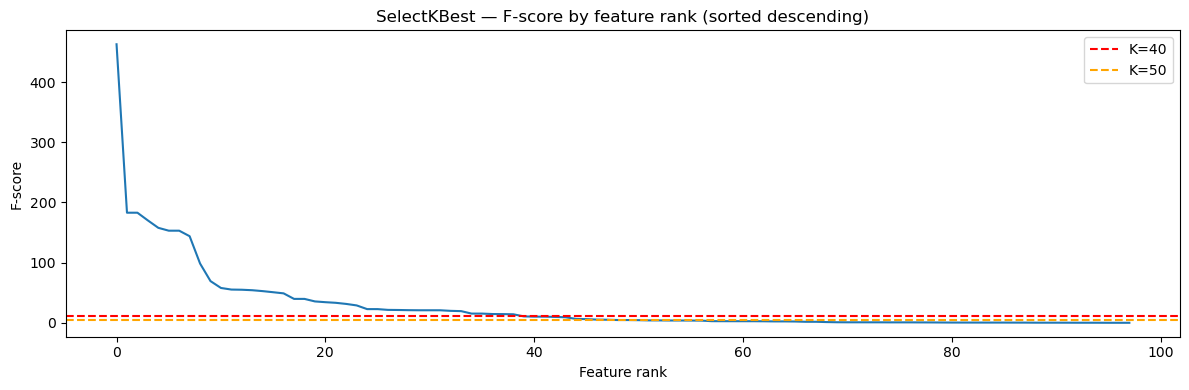

Score at K=40:  10.66
Score at K=50:  4.57
Score at K=60:  2.65


In [13]:
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_dense_all   = X_processed.toarray()       if hasattr(X_processed,       "toarray") else X_processed

# Fit VarianceThreshold on training data only — drops same column(s) from all sets
n_before_vt = X_train_dense.shape[1]
vt = VarianceThreshold(threshold=0)
X_train_dense = vt.fit_transform(X_train_dense)
X_dense_all   = vt.transform(X_dense_all)
print(f"Removed {n_before_vt - X_train_dense.shape[1]} constant feature(s). Feature matrix: {n_before_vt} → {X_train_dense.shape[1]}")

# Diagnostic scoring on training data only
diagnostics = SelectKBest(score_func=f_classif, k="all")
diagnostics.fit(X_train_dense, y_train_nb02)

sorted_scores = sorted(diagnostics.scores_, reverse=True)

plt.figure(figsize=(12, 4))
plt.plot(sorted_scores, linewidth=1.5)
plt.axhline(y=sorted_scores[39], color="red",    linestyle="--", label="K=40")
plt.axhline(y=sorted_scores[49], color="orange", linestyle="--", label="K=50")
plt.xlabel("Feature rank")
plt.ylabel("F-score")
plt.title("SelectKBest — F-score by feature rank (sorted descending)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Score at K=40:  {sorted_scores[39]:.2f}")
print(f"Score at K=50:  {sorted_scores[49]:.2f}")
print(f"Score at K=60:  {sorted_scores[59]:.2f}")

### Comparing Feature Selection Scoring Functions

Two scoring functions are evaluated to justify the choice of ANOVA F-score (`f_classif`):
- **ANOVA F-score (`f_classif`):** Measures linear association between each feature and the target via an F-test. Fast and well-suited to continuous features.
- **Mutual Information (`mutual_info_classif`):** Captures non-linear dependencies between features and the target. More general but higher variance and computationally slower.

Both are evaluated at K=50 via 5-fold stratified CV using the same `ImbPipeline` setup, with F1 as the scoring metric.

In [14]:
from sklearn.feature_selection import mutual_info_classif
import warnings

fs_methods = {
    "ANOVA F-score (f_classif)":      f_classif,
    "Mutual Information":              mutual_info_classif,
}

cv_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fs_results = []

for method_name, score_func in fs_methods.items():
    skb = SelectKBest(score_func=score_func, k=50)
    pipeline = ImbPipeline([
        ("select",      skb),
        ("undersample", RandomUnderSampler(random_state=42)),
        ("model",       LogisticRegression(max_iter=2000, random_state=42))
    ])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        scores = cross_val_score(pipeline, X_train_dense, y_train_nb02, cv=cv_fs, scoring="f1")
    fs_results.append({"Method": method_name, "Mean F1": round(scores.mean(), 4), "Std": round(scores.std(), 4)})
    print(f"{method_name}: F1={scores.mean():.4f} ± {scores.std():.4f}")

print("\nFeature Selection Scoring Function Comparison (K=50):")
print(pd.DataFrame(fs_results).to_string(index=False))
print("\n→ ANOVA F-score selected: highest mean F1, lower variance, and faster computation.")

ANOVA F-score (f_classif): F1=0.4448 ± 0.0101
Mutual Information: F1=0.4415 ± 0.0076

Feature Selection Scoring Function Comparison (K=50):
                   Method  Mean F1    Std
ANOVA F-score (f_classif)   0.4448 0.0101
       Mutual Information   0.4415 0.0076

→ ANOVA F-score selected: highest mean F1, lower variance, and faster computation.


### Validating K — Cross-Validated F1 Across Candidate Values

Visual inspection of the score plot suggests the curve flattens markedly around K=50. To confirm this empirically, a Logistic Regression model is evaluated via 5-fold stratified cross-validation across a range of candidate K values, including the full feature set (K=98) as a baseline. Under-sampling is applied inside the `ImbPipeline` at each fold to prevent leakage from the validation fold. F1-score is used as the evaluation metric throughout, consistent with the primary metric adopted for this project.

The K value that retains equivalent F1 to the full feature set whilst achieving the greatest dimensionality reduction is selected. A drop within the range of cross-validation noise (approximately one standard deviation) is considered acceptable.

In [15]:
n_features = X_train_dense.shape[1]  # after constant removal
k_candidates = [15, 20, 25, 30, 35, 50, 75, n_features]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
validation_results = []

for k in k_candidates:
    skb = SelectKBest(score_func=f_classif, k=k if k < n_features else "all")
    pipeline = ImbPipeline([
        ("select",      skb),
        ("undersample", RandomUnderSampler(random_state=42)),
        ("model",       LogisticRegression(max_iter=2000, random_state=42))
    ])
    scores = cross_val_score(pipeline, X_train_dense, y_train_nb02, cv=cv, scoring="f1")
    validation_results.append({"K": k, "Mean F1": round(scores.mean(), 4), "Std": round(scores.std(), 4)})
    print(f"K={k:<4}  F1={scores.mean():.4f} ± {scores.std():.4f}")

validation_df = pd.DataFrame(validation_results)
print(f"\nFull feature set (K={n_features}): {validation_df[validation_df['K'] == n_features]['Mean F1'].values[0]}")

K=15    F1=0.4162 ± 0.0081
K=20    F1=0.4244 ± 0.0085
K=25    F1=0.4339 ± 0.0056
K=30    F1=0.4336 ± 0.0057
K=35    F1=0.4380 ± 0.0055
K=50    F1=0.4448 ± 0.0101
K=75    F1=0.4473 ± 0.0086
K=98    F1=0.4470 ± 0.0086

Full feature set (K=98): 0.447


The cross-validation results confirm the elbow at K=50. The F1 drop from the full feature set (K=98) to K=50 is approximately 0.0022 — within the range of cross-validation noise (standard deviation ~0.0086) — meaning the reduction is not statistically meaningful. Values below K=50 show more substantial drops in F1, indicating those features carry useful signal. **K=50 is therefore selected**: it achieves approximately 50% dimensionality reduction (98 → 50 features) with no significant loss in predictive performance. The selector is fitted on the full training set and applied to all other sets using `transform()` only, preserving the leakage-free pipeline.

In [16]:
# K=50 selected: F1 drop vs baseline is within CV noise — see markdown above
K = 50

selector = SelectKBest(score_func=f_classif, k=K)
selector.fit(X_train_dense, y_train_nb02)       # fit on training rows only

X_all_selected     = selector.transform(X_dense_all)  # transform all rows (train + test)

X_holdout_dense    = X_holdout_processed.toarray() if hasattr(X_holdout_processed, "toarray") else X_holdout_processed
X_holdout_dense    = vt.transform(X_holdout_dense)
X_holdout_selected = selector.transform(X_holdout_dense)

print(f"Selector fitted on training rows only: {X_train_dense.shape[1]} → {K} features")
print(f"Full processed dataset: {X_all_selected.shape}")
print(f"Processed holdout:      {X_holdout_selected.shape}")

Selector fitted on training rows only: 98 → 50 features
Full processed dataset: (51047, 50)
Processed holdout:      (20000, 50)


## Save Processed Outputs

In [17]:
BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save fitted preprocessor and selector for reuse in later notebooks
joblib.dump(preprocessor, MODELS_DIR / "preprocessing_pipeline.joblib")
joblib.dump(selector, MODELS_DIR / "feature_selector.joblib")

pd.DataFrame(X_all_selected).to_csv(PROCESSED_DIR / "cell2celltrain_processed.csv", index=False)
y.to_csv(PROCESSED_DIR / "cell2celltrain_target.csv", index=False)
pd.DataFrame(X_holdout_selected).to_csv(PROCESSED_DIR / "cell2cellholdout_processed.csv", index=False)

print("Saved to:", PROCESSED_DIR)
print("  - cell2celltrain_processed.csv")
print("  - cell2celltrain_target.csv")
print("  - cell2cellholdout_processed.csv")
print("Pipeline saved to:", MODELS_DIR / "preprocessing_pipeline.joblib")
print("Selector saved to:", MODELS_DIR / "feature_selector.joblib")

Saved to: /Users/abbasq/Uni/third-year/IP/data/processed
  - cell2celltrain_processed.csv
  - cell2celltrain_target.csv
  - cell2cellholdout_processed.csv
Pipeline saved to: /Users/abbasq/Uni/third-year/IP/models/preprocessing_pipeline.joblib
Selector saved to: /Users/abbasq/Uni/third-year/IP/models/feature_selector.joblib


## Summary

This notebook produced a clean, model-ready dataset from the raw Cell2Cell training and holdout files. The key decisions were:

- **Dropped:** `CustomerID` (identifier), `ServiceArea` (747-cardinality, leakage risk), `NotNewCellphoneUser` (redundant with `NewCellphoneUser` — strong correlation confirmed via crosstab)
- **Hidden missingness resolved:** `'Unknown'` strings in `HandsetPrice`, `MaritalStatus`, and `Homeownership` replaced with NaN prior to imputation
- **Imputation:** Median for numerical features (robust to outliers); most-frequent for categorical features
- **Encoding:** One-hot with `handle_unknown='ignore'` for safe application to the holdout set
- **Constant feature removed:** `Homeownership` became constant post-imputation (all `'Known'`) and was removed by `VarianceThreshold` (99 → 98 features)
- **IncomeGroup=0 verified:** Confirmed as a valid low-income tier, not a missing-value code — retained as-is
- **Feature selection:** `SelectKBest` (ANOVA F-score, K=50) selected empirically via 5-fold CV — F1 drop vs full feature set is within noise (98 → 50 features)
- **No leakage:** Pipeline fitted on 80% training rows only; test and holdout sets transformed without refitting

**Outputs saved to `data/processed/`:**
- `cell2celltrain_processed.csv` — 51,047 × 50 processed training features
- `cell2celltrain_target.csv` — binary churn labels
- `cell2cellholdout_processed.csv` — 20,000 × 50 processed holdout features

**Next:** Notebook 03 evaluates class imbalance handling strategies (class weighting, SMOTE, random under-sampling) using the processed dataset produced here.